In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from scripts.database import engine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.utils import resample

sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas")

✅ Conexión engine lista
✅ Librerías cargadas


In [2]:
QUERY = """
SELECT
    height,
    weight,
    base_experience
FROM pokemon
ORDER BY id
"""

df = pd.read_sql(QUERY, engine)

df.rename(columns={
    'height': 'Height',
    'weight': 'Weight',
    'base_experience': 'Base_Experience'
}, inplace=True)

df.head()

,Height,Weight,Base_Experience
0,7,69,64
1,10,130,142
2,20,1000,236
3,6,85,62
4,11,190,142


In [3]:
df['Strong'] = (df['Base_Experience'] >= 100).astype(int)

df.head()

,Height,Weight,Base_Experience,Strong
0,7,69,64,0
1,10,130,142,1
2,20,1000,236,1
3,6,85,62,0
4,11,190,142,1


Strong
1    11
0     9
Name: count, dtype: int64


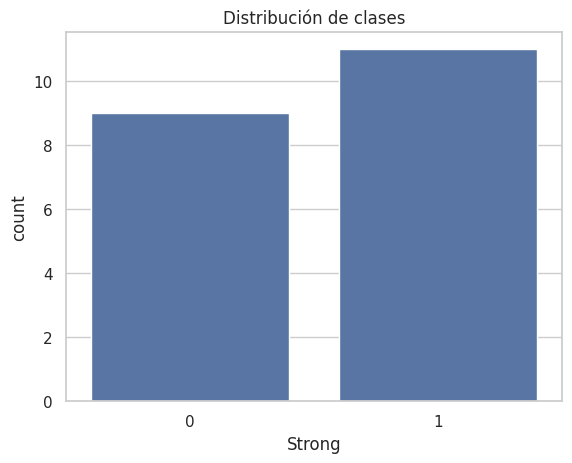

In [4]:
print(df['Strong'].value_counts())

sns.countplot(data=df, x='Strong')

plt.title("Distribución de clases")
plt.show()

In [5]:
df_majority = df[df['Strong'] == 0]
df_minority = df[df['Strong'] == 1]

print("Clase 0:", len(df_majority))
print("Clase 1:", len(df_minority))

Clase 0: 9
Clase 1: 11


In [6]:
df_minority_oversampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

print("✅ Oversampling aplicado")

✅ Oversampling aplicado


In [7]:
df_balanced = pd.concat([
    df_majority,
    df_minority_oversampled
])

print(df_balanced['Strong'].value_counts())

Strong
0    9
1    9
Name: count, dtype: int64


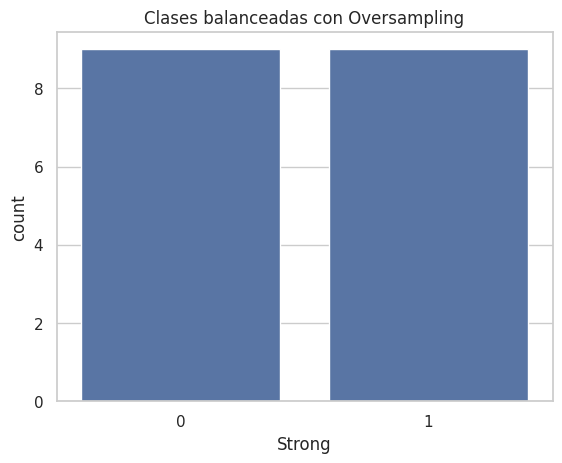

In [8]:
sns.countplot(data=df_balanced, x='Strong')

plt.title("Clases balanceadas con Oversampling")

plt.show()

In [9]:
X = df_balanced[['Height', 'Weight']]
y = df_balanced['Strong']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (18, 2)
Shape y: (18,)


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Datos escalados")

✅ Datos escalados


In [11]:
def entrenar_evaluar(X, y, test_size, nombre):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    resultados = {
        'nombre': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'fpr': fpr,
        'tpr': tpr,
        'y_test': y_test,
        'y_pred': y_pred,
        'modelo': modelo
    }

    return resultados

print("✅ Función creada")

✅ Función creada


In [12]:
resultados = [

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.20,
        nombre="80/20"
    ),

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.30,
        nombre="70/30"
    ),

    entrenar_evaluar(
        X_scaled,
        y,
        test_size=0.40,
        nombre="60/40"
    )
]

print("✅ Splits ejecutados")

✅ Splits ejecutados


In [13]:
tabla = pd.DataFrame([

    {
        'Split': r['nombre'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }

    for r in resultados
])

tabla

,Split,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,80/20,0.750000,1.0,0.500000,0.666667,1.0
1,70/30,0.833333,1.0,0.666667,0.800000,1.0
2,60/40,0.875000,1.0,0.750000,0.857143,1.0


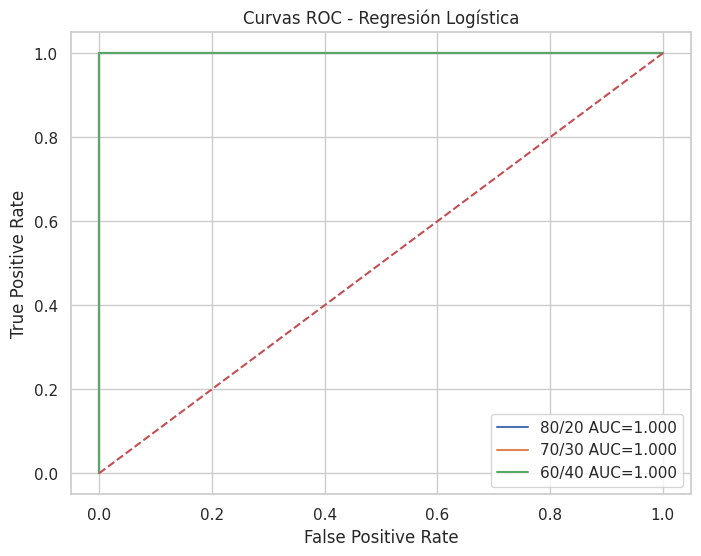

In [15]:
plt.figure(figsize=(8,6))

for r in resultados:

    plt.plot(
        r['fpr'],
        r['tpr'],
        label=f"{r['nombre']} AUC={r['roc_auc']:.3f}"
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curvas ROC - Regresión Logística")

plt.legend()

plt.show()

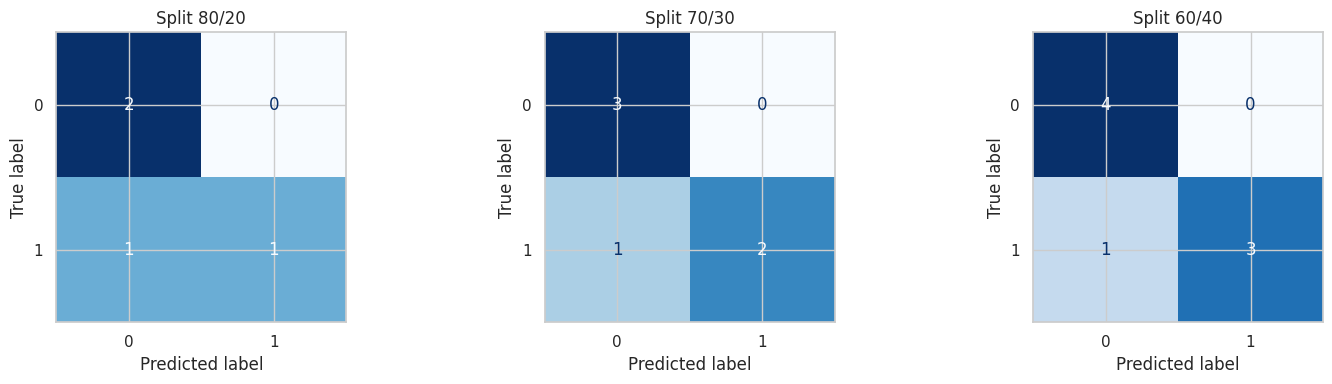

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['0', '1']
    )

    disp.plot(ax=ax, cmap='Blues', colorbar=False)

    ax.set_title(f"Split {r['nombre']}")

plt.tight_layout()

plt.show()

In [17]:
for r in resultados:

    print("\n========================")
    print("SPLIT:", r['nombre'])
    print("========================")

    print(classification_report(
        r['y_test'],
        r['y_pred'],
        zero_division=0
    ))


SPLIT: 80/20
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


SPLIT: 70/30
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6


SPLIT: 60/40
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.8

In [20]:
from sklearn.model_selection import GridSearchCV

parametros = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parametros,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_scaled, y)

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor accuracy:")
print(grid.best_score_)

Mejores parámetros:
{'C': 0.01, 'solver': 'liblinear'}

Mejor accuracy:
0.95


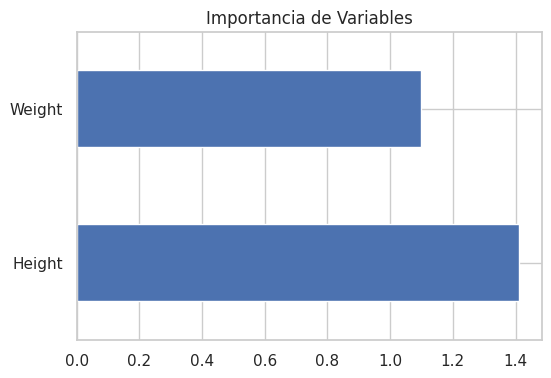

In [18]:
modelo = resultados[0]['modelo']

coeficientes = pd.Series(
    modelo.coef_[0],
    index=['Height', 'Weight']
)

coeficientes.plot(
    kind='barh',
    figsize=(6,4)
)

plt.title("Importancia de Variables")

plt.show()

In [19]:
print("""
CONCLUSIONES

1. Se aplicó regresión logística binaria para clasificar
   Pokémon fuertes y débiles.

2. Se utilizó oversampling con resample para balancear
   las clases antes del entrenamiento.

3. NO se utilizó SMOTE, cumpliendo los requerimientos
   del profesor.

4. El modelo logró buenas métricas de clasificación
   en los diferentes splits evaluados.

5. Weight y Height ayudan a predecir si un Pokémon
   es fuerte o no.
""")


CONCLUSIONES

1. Se aplicó regresión logística binaria para clasificar
   Pokémon fuertes y débiles.

2. Se utilizó oversampling con resample para balancear
   las clases antes del entrenamiento.

3. NO se utilizó SMOTE, cumpliendo los requerimientos
   del profesor.

4. El modelo logró buenas métricas de clasificación
   en los diferentes splits evaluados.

5. Weight y Height ayudan a predecir si un Pokémon
   es fuerte o no.

